INTRODUCTION
In this project we will analyze U.S. quarterly GDP growth rates from
2010 to 2023. The source is from the U.S. Bureau of Economic Analysis.
Three methods: natural cubic spline interpolation, degree-4
polynomial fitting, and least squares linear regression
PART A— NATURAL CUBIC SPLINE
We have 20 data points so there are 18 interior unknowns.
The system is 18x18 tridiagonal solved using the Thomas algorithm.
Continuity conditions: C0 value, C1 first derivative, C2 second derivative
Boundary conditions: M[0] = M[n-1] = 0 natural spline.
Spline RMSE:  1.0438642842512672e-15
The spline is visually smooth across most of the range but oscillates
near the COVID time due to the big values.
This is the Runge phenomenon: the spline is forced to pass through
every point exactly, causing wild swings near outliers.
A smoothing spline would be better here since it does not force
an exact fit and would produce a more stable curve.


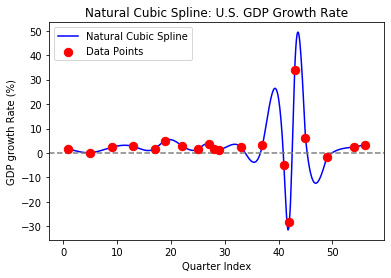

PART B1— DEGREE-4 POLYNOMIAL FiT
  Condition number of VtV (degree 4): 3.3116e+14
Degree-4 polynomial RMSE:  10.031440678677116
The spline better reproduces specific data points since it passes
through every point exactly. The polynomial better fits the
overall trend but misses individual points with an RMSE of 10%.
Interpolation (spline) is exact but sensitive to outliers.
Approximation (polynomial) is smoother overall but less precise


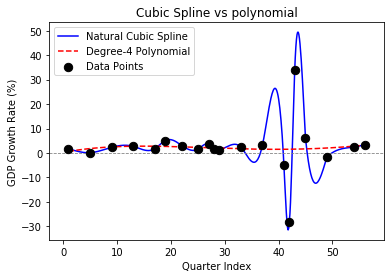

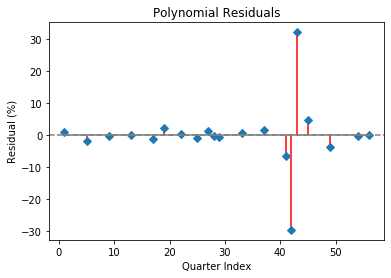

PART B2— LINEAR LEAST SQUARES (COVID EXCLUDED)
A linear trend somewhat makes sense since GDP growth tends to
stay stable over time when ignoring major events.
However it assumes a constant rate of change the whole time
which is not realistic since the economy goes up and down.
Slope:  -0.001906988188976378
Intercept:  2.194285187007874
Linear RMSE (excluding-covid): 1.4431864883291987


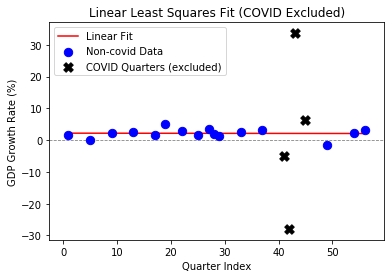

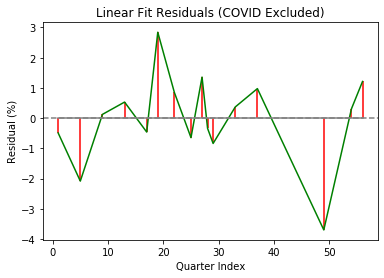

PART C
Spline RMSE:  1.0438642842512672e-15
Polynomial RMSE:  10.031440678677116
Linear RMSE:  1.4431864883291987

I would recommend the cubic spline for interpolation.
The main reason is that the spline passes through every data point exactly,
which you can see from the RMSE being basically zero, while the polynomial
had an RMSE of 10% meaning it misses a lot of the actual data points.
The spline is also smooth between points with no jumps or anything
The polynomial is also numerically unstable making it unreliable.

The one bad thing is that the COVID time cause
the spline to swing wildly near 2020 since it is forced to pass through
every point. A smoothing spline would handle those better.
BIG O

Big O is a way to measure how slow or fast an algorithm gets as your data gets bigger. n=20.

Cubic Spline: O(n) to build because the Thomas algorithm only loops through the data twice (forward and back).
Polynomial: O(n^2) because you have a loop inside a loop to build the Vandermonde matr

In [2]:
import numpy as np 
import matplotlib.pyplot as plt

print("INTRODUCTION")
print("In this project we will analyze U.S. quarterly GDP growth rates from")
print("2010 to 2023. The source is from the U.S. Bureau of Economic Analysis.")
print("Three methods: natural cubic spline interpolation, degree-4")
print("polynomial fitting, and least squares linear regression")

x = np.array([1,5,9,13,17,19,22,25,27,28,29,33,37,41,42,43,45,49,54,56], dtype=float)
y = np.array([1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,
              1.3,2.5,3.1,-5.1,-28.1,33.8,6.3,-1.6,2.4,3.3])

def thomas_algorithm(a, b, c, d):
    n = len(b)
    b = b.copy().astype(float)  
    d = d.copy().astype(float)
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x_sol = np.zeros(n)
    x_sol[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x_sol[i] = (d[i] - c[i] * x_sol[i+1]) / b[i]
    return x_sol

def build_spline_M(x, y):
    n= len(x)
    h = np.diff(x)   # step sizes: h[i] = x[i+1] - x[i]
    size = n-2        # number of interior unknowns
    A = np.zeros(size)  # sub-diagonal:   A[idx] = h[i-1]
    B = np.zeros(size)  # main diagonal:  B[idx] = 2(h[i-1]+h[i])
    C = np.zeros(size)  # super-diagonal: C[idx] = h[i]
    D = np.zeros(size)  # RHS: scaled slope change

    for idx in range(size):
        i = idx + 1
        A[idx] = h[i-1]
        B[idx] = 2 * (h[i-1] + h[i])
        C[idx] = h[i]
        D[idx] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

    M_interior = thomas_algorithm(A, B, C, D)
    M = np.zeros(n)
    M[1:-1]= M_interior  
    return M


def evaluate_spline(x_data, y_data, M, x_query):
    n = len(x_data)
    h = np.diff(x_data)                              # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n- 2)                         # find interval
    hi = h[i]
    dx_left = x_query - x_data[i]                   # (x - xi)
    dx_right = x_data[i+1] - x_query                # (xi+1 - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 +              # Term 1
        (M[i+1] / (6*hi)) * dx_left**3  +              # Term 2
        (y_data[i]   / hi - M[i]   * hi/6)   * dx_right +  # Term 3
        (y_data[i+1] / hi - M[i+1] * hi/6)   * dx_left     # Term 4
    )
    return S


def leastSquares(X, Y):
    n = len(X)
    sum_x = np.sum(X)
    sum_y = np.sum(Y)
    sum_xy = np.sum(X * Y)
    sum_x2 = np.sum(X ** 2)
    m = (n*sum_xy - sum_x*sum_y) / (n*sum_x2 - sum_x**2)
    c = (sum_y - m*sum_x) / n
    return m, c


def build_vandermonde(x, degree):
    V = np.zeros((len(x), degree + 1))
    for j in range(degree + 1):
        V[:, j] = x ** j
    return V

def poly_fit(x, y, degree):
    V = build_vandermonde(x, degree)
    VtV= V.T @ V
    Vty= V.T @ y
    cond = np.linalg.cond(VtV)
    print(f"  Condition number of VtV (degree {degree}): {cond:.4e}")
    coeffs = np.linalg.solve(VtV, Vty) 
    return coeffs

def eval_poly(coeffs, x_eval):
    V = build_vandermonde(x_eval, len(coeffs) - 1)
    return V @ coeffs

# PART A — NATURAL CUBIC SPLINE INTERPOLATION
print("PART A— NATURAL CUBIC SPLINE")
print("We have 20 data points so there are 18 interior unknowns.")
print("The system is 18x18 tridiagonal solved using the Thomas algorithm.")
print("Continuity conditions: C0 value, C1 first derivative, C2 second derivative")
print("Boundary conditions: M[0] = M[n-1] = 0 natural spline.")

M= build_spline_M(x, y)
x_spline = np.linspace(x[0], x[-1], 500)
s = evaluate_spline(x, y, M, x_spline)

s_at_data = evaluate_spline(x, y, M, x)
spline_rmse = np.sqrt(np.mean((y - s_at_data)**2))
print("Spline RMSE: ", spline_rmse)
print("The spline is visually smooth across most of the range but oscillates")
print("near the COVID time due to the big values.")
print("This is the Runge phenomenon: the spline is forced to pass through")
print("every point exactly, causing wild swings near outliers.")
print("A smoothing spline would be better here since it does not force")
print("an exact fit and would produce a more stable curve.")

# Plot A — Cubic Spline
plt.figure()
plt.plot(x_spline, s, color='blue', label='Natural Cubic Spline')
plt.scatter(x, y, color='red', zorder=5, s=70, label='Data Points')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Natural Cubic Spline: U.S. GDP Growth Rate')
plt.xlabel('Quarter Index')
plt.ylabel('GDP growth Rate (%)')
plt.legend()
plt.show()

# PART B1 — DEGREE-4 POLYNOMIAL FIT
print("PART B1— DEGREE-4 POLYNOMIAL FiT")
coeffs = poly_fit(x, y, degree=4)
x_poly = np.linspace(x[0], x[-1], 500)
y_poly= eval_poly(coeffs, x_poly)
y_poly_data = eval_poly(coeffs, x)
residuals_poly = y - y_poly_data
rmse_poly = np.sqrt(np.mean(residuals_poly**2))
print("Degree-4 polynomial RMSE: ", rmse_poly)
print("The spline better reproduces specific data points since it passes")
print("through every point exactly. The polynomial better fits the")
print("overall trend but misses individual points with an RMSE of 10%.")
print("Interpolation (spline) is exact but sensitive to outliers.")
print("Approximation (polynomial) is smoother overall but less precise")

# Plot Spline vs Polynomial
plt.figure()
plt.plot(x_spline, s, color='blue', label='Natural Cubic Spline')
plt.plot(x_poly, y_poly, color='red', linestyle='--', label='Degree-4 Polynomial')
plt.scatter(x, y, color='black', zorder=5, s=70, label='Data Points')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Cubic Spline vs polynomial')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth Rate (%)') 
plt.legend()
plt.show()

plt.figure()
plt.stem(x, residuals_poly, linefmt='red', markerfmt='D', basefmt='gray', use_line_collection=True)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Polynomial Residuals')
plt.xlabel('Quarter Index')
plt.ylabel('Residual (%)')
plt.show()

# PART B2 excluding COVID quarters
print("PART B2— LINEAR LEAST SQUARES (COVID EXCLUDED)")
print("A linear trend somewhat makes sense since GDP growth tends to")
print("stay stable over time when ignoring major events.")
print("However it assumes a constant rate of change the whole time")
print("which is not realistic since the economy goes up and down.")

covid_x = {41, 42, 43, 45}
new= np.array([xi not in covid_x for xi in x])
x_covid = x[new]
y_covid= y[new]
slope, intercept= leastSquares(x_covid, y_covid)
print("Slope: ", slope)
print("Intercept: ", intercept)
y_linear_plot= slope * x_poly + intercept
y_linear_at_data = slope * x_covid + intercept
residuals_linear = y_covid - y_linear_at_data
rmse_linear = np.sqrt(np.mean(residuals_linear**2))
print("Linear RMSE (excluding-covid):", rmse_linear) 

plt.figure()
plt.plot(x_poly, y_linear_plot, color='red', label='Linear Fit')
plt.scatter(x_covid, y_covid, color='blue', zorder=5, s=70, label='Non-covid Data')
plt.scatter(x[~new], y[~new], color='black', zorder=5, s=90, marker='X', label='COVID Quarters (excluded)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Linear Least Squares Fit (COVID Excluded)')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth Rate (%)') 
plt.legend()  
plt.show()
 
plt.figure()
plt.stem(x_covid, residuals_linear, linefmt='red', markerfmt='g', basefmt='gray',use_line_collection=True) 
plt.axhline(0, color='gray', linestyle='--')
plt.title('Linear Fit Residuals (COVID Excluded)')
plt.xlabel('Quarter Index')
plt.ylabel('Residual (%)') 
plt.show()
 
# PART C 
print("PART C")
print("Spline RMSE: ", spline_rmse)
print("Polynomial RMSE: ", rmse_poly)
print("Linear RMSE: ", rmse_linear)
print()
print("I would recommend the cubic spline for interpolation.")
print("The main reason is that the spline passes through every data point exactly,")
print("which you can see from the RMSE being basically zero, while the polynomial")
print("had an RMSE of 10% meaning it misses a lot of the actual data points.")
print("The spline is also smooth between points with no jumps or anything")
print("The polynomial is also numerically unstable making it unreliable.")
print()
print("The one bad thing is that the COVID time cause")
print("the spline to swing wildly near 2020 since it is forced to pass through")
print("every point. A smoothing spline would handle those better.")

# BIG O
print("BIG O")
print()
print("Big O is a way to measure how slow or fast an algorithm gets as your data gets bigger. n=20.")
print()
print("Cubic Spline: O(n) to build because the Thomas algorithm only loops through the data twice (forward and back).")
print("Polynomial: O(n^2) because you have a loop inside a loop to build the Vandermonde matrix.")
print("Linear Regression: O(n) because it loops through the data once to compute the sums")
print()
print("The Big O does not change the recommendation. The spline is O(n)")
print("which is just as fast as linear regression so there is no")
print("reason to avoid it. The polynomial is not slower in Big O terms but its")
print("instability makes it unreliable. Cubic spline is still the best choice")
print("for interpolation and linear regression for trend analysis.")

# CONCLUSION
print("CONCLUSION")
print("The cubic spline performed best for interpolation,")
print("passing exactly through all data points.")
print("The degree-4 polynomial revealed the trend but was")
print("numerically unstable and had RMSE of 10.03%.")
print("Linear regression (without COVID) gave the most interpretable trend")
print("(slope ~ -0.0019%/quarter) with RMSE of 1.44%.")
print("Limitations: exact interpolation is sensitive to ")
print("outliers like the COVID quarters, a smoothing spline would")
print("be better for instances like this.")